To do: 
- analyse (plots, exploration, outliers?)
- risk analysis

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import re
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import warnings
warnings.filterwarnings('ignore')

In [37]:
# Set style
plt.style.use('ggplot')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 6)

# Load data
df = pd.read_csv('WELFake_Dataset.csv')
print("=== DATASET OVERVIEW ===")
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nLabel distribution:")
print(df['label'].value_counts())
print(f"\nLabel percentages:")
print(df['label'].value_counts(normalize=True).mul(100).round(2))

# Check for missing values
print(f"\nMissing values:")
print(df.isnull().sum())

# Verify label meaning (assuming 0=FAKE, 1=REAL)
label_map = {0: 'FAKE', 1: 'REAL'}
df['label_name'] = df['label'].map(label_map)

# Sample data
print(f"\nSample REAL news:")
print(df[df['label'] == 1]['title'].head(3).tolist())
print(f"\nSample FAKE news:")
print(df[df['label'] == 0]['title'].head(3).tolist())

=== DATASET OVERVIEW ===
Shape: (72134, 4)

Columns: ['Unnamed: 0', 'title', 'text', 'label']

Label distribution:
label
1    37106
0    35028
Name: count, dtype: int64

Label percentages:
label
1    51.44
0    48.56
Name: proportion, dtype: float64

Missing values:
Unnamed: 0      0
title         558
text           39
label           0
dtype: int64

Sample REAL news:
['LAW ENFORCEMENT ON HIGH ALERT Following Threats Against Cops And Whites On 9-11By #BlackLivesMatter And #FYF911 Terrorists [VIDEO]', nan, 'UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MOST CHARLOTTE RIOTERS WERE “PEACEFUL” PROTESTERS…In Her Home State Of North Carolina [VIDEO]']

Sample FAKE news:
['Bobby Jindal, raised Hindu, uses story of Christian conversion to woo evangelicals for potential 2016 bid', 'May Brexit offer would hurt, cost EU citizens - EU parliament', 'Schumer calls on Trump to appoint official to oversee Puerto Rico relief']


0=Fake, 1=Real

- Balanced dataset
- Few null values


Filtered out 675 articles with title length > 200
Filtered out 18457 articles with text length > 4000


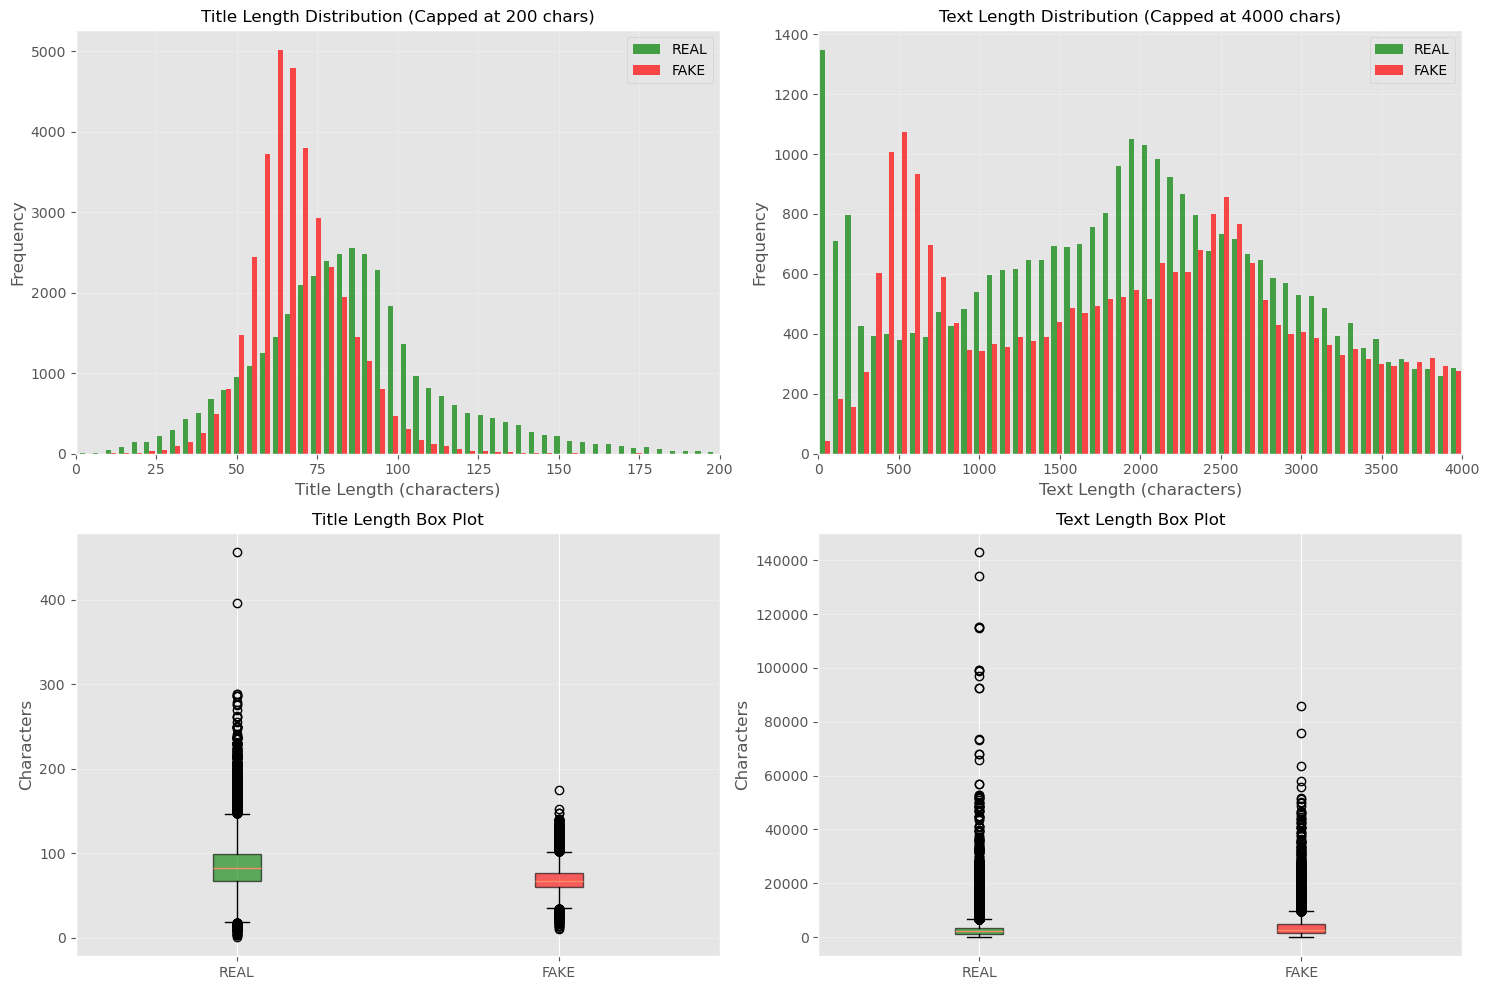


LENGTH STATISTICS BY NEWS TYPE

📊 TITLE LENGTH (characters):
            count  mean   std   min   25%   50%   75%    max
FAKE (0)  35028.0  68.8  14.4  10.0  60.0  67.0  77.0  175.0
REAL (1)  36548.0  85.1  30.0   1.0  67.0  83.0  99.0  456.0

📊 TEXT LENGTH (characters):
            count    mean     std  min     25%     50%     75%       max
FAKE (0)  35028.0  3495.3  3325.5  1.0  1477.0  2642.5  4757.2   85948.0
REAL (1)  37067.0  3057.4  4069.7  1.0  1317.0  2211.0  3430.0  142961.0

KEY INSIGHTS

🔍 Title Length:
   - REAL news average: 85.1 chars
   - FAKE news average: 68.8 chars
   - Difference: 16.4 chars
   - REAL news tends to have longer titles

🔍 Text Length:
   - REAL news average: 3057.4 chars
   - FAKE news average: 3495.3 chars
   - Difference: 437.9 chars
   - FAKE news tends to have longer articles


In [38]:
label_map = {1: 'REAL', 0: 'FAKE'}
df['label_name'] = df['label'].map(label_map)

# Add text length features
df['title_length'] = df['title'].str.len()
df['text_length'] = df['text'].str.len()
df['word_count_title'] = df['title'].str.split().str.len()
df['word_count_text'] = df['text'].str.split().str.len()

# Filter out extreme outliers for better visualization
title_cap = 200
text_cap = 4000

df_title_filtered = df[df['title_length'] <= title_cap]
df_text_filtered = df[df['text_length'] <= text_cap]

print(f"\nFiltered out {len(df) - len(df_title_filtered)} articles with title length > {title_cap}")
print(f"Filtered out {len(df) - len(df_text_filtered)} articles with text length > {text_cap}")

# Title length distribution by label
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Title length histogram with x-axis limit
axes[0,0].hist([df_title_filtered[df_title_filtered['label']==1]['title_length'], 
                df_title_filtered[df_title_filtered['label']==0]['title_length']], 
               label=['REAL', 'FAKE'], bins=50, alpha=0.7, color=['green', 'red'])
axes[0,0].set_title('Title Length Distribution (Capped at 200 chars)', fontsize=12)
axes[0,0].set_xlabel('Title Length (characters)')
axes[0,0].set_ylabel('Frequency')
axes[0,0].set_xlim(0, title_cap)
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Text length histogram with x-axis limit
axes[0,1].hist([df_text_filtered[df_text_filtered['label']==1]['text_length'], 
                df_text_filtered[df_text_filtered['label']==0]['text_length']], 
               label=['REAL', 'FAKE'], bins=50, alpha=0.7, color=['green', 'red'])
axes[0,1].set_title('Text Length Distribution (Capped at 4000 chars)', fontsize=12)
axes[0,1].set_xlabel('Text Length (characters)')
axes[0,1].set_ylabel('Frequency')
axes[0,1].set_xlim(0, text_cap)
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Box plot for title length
title_data = [
    df[df['label']==1]['title_length'].dropna(),  # REAL
    df[df['label']==0]['title_length'].dropna()   # FAKE
]

bp1 = axes[1,0].boxplot(title_data, labels=['REAL', 'FAKE'], patch_artist=True)
axes[1,0].set_title('Title Length Box Plot', fontsize=12)
axes[1,0].set_ylabel('Characters')
axes[1,0].grid(True, alpha=0.3, axis='y')

# Color the boxes
colors = ['green', 'red']
for patch, color in zip(bp1['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

# Box plot for text length 
text_data = [
    df[df['label']==1]['text_length'].dropna(),   # REAL
    df[df['label']==0]['text_length'].dropna()    # FAKE
]

bp2 = axes[1,1].boxplot(text_data, labels=['REAL', 'FAKE'], patch_artist=True)
axes[1,1].set_title('Text Length Box Plot', fontsize=12)
axes[1,1].set_ylabel('Characters')
axes[1,1].grid(True, alpha=0.3, axis='y')

# Color the boxes
for patch, color in zip(bp2['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

plt.tight_layout()
plt.show()

# Summary statistics with clear label mapping
print("\n" + "="*60)
print("LENGTH STATISTICS BY NEWS TYPE")
print("="*60)

print("\n📊 TITLE LENGTH (characters):")
title_stats = df.groupby('label')['title_length'].describe().round(1)
title_stats.index = ['FAKE (0)', 'REAL (1)']  # Rename for clarity
print(title_stats)

print("\n📊 TEXT LENGTH (characters):")
text_stats = df.groupby('label')['text_length'].describe().round(1)
text_stats.index = ['FAKE (0)', 'REAL (1)']  # Rename for clarity
print(text_stats)

# Additional useful statistics
print("\n" + "="*60)
print("KEY INSIGHTS")
print("="*60)

real_mean_title = df[df['label']==1]['title_length'].mean()
fake_mean_title = df[df['label']==0]['title_length'].mean()
real_mean_text = df[df['label']==1]['text_length'].mean()
fake_mean_text = df[df['label']==0]['text_length'].mean()

print(f"\n🔍 Title Length:")
print(f"   - REAL news average: {real_mean_title:.1f} chars")
print(f"   - FAKE news average: {fake_mean_title:.1f} chars")
print(f"   - Difference: {abs(real_mean_title - fake_mean_title):.1f} chars")
print(f"   - {'FAKE' if fake_mean_title > real_mean_title else 'REAL'} news tends to have longer titles")

print(f"\n🔍 Text Length:")
print(f"   - REAL news average: {real_mean_text:.1f} chars")
print(f"   - FAKE news average: {fake_mean_text:.1f} chars")
print(f"   - Difference: {abs(real_mean_text - fake_mean_text):.1f} chars")
print(f"   - {'FAKE' if fake_mean_text > real_mean_text else 'REAL'} news tends to have longer articles")

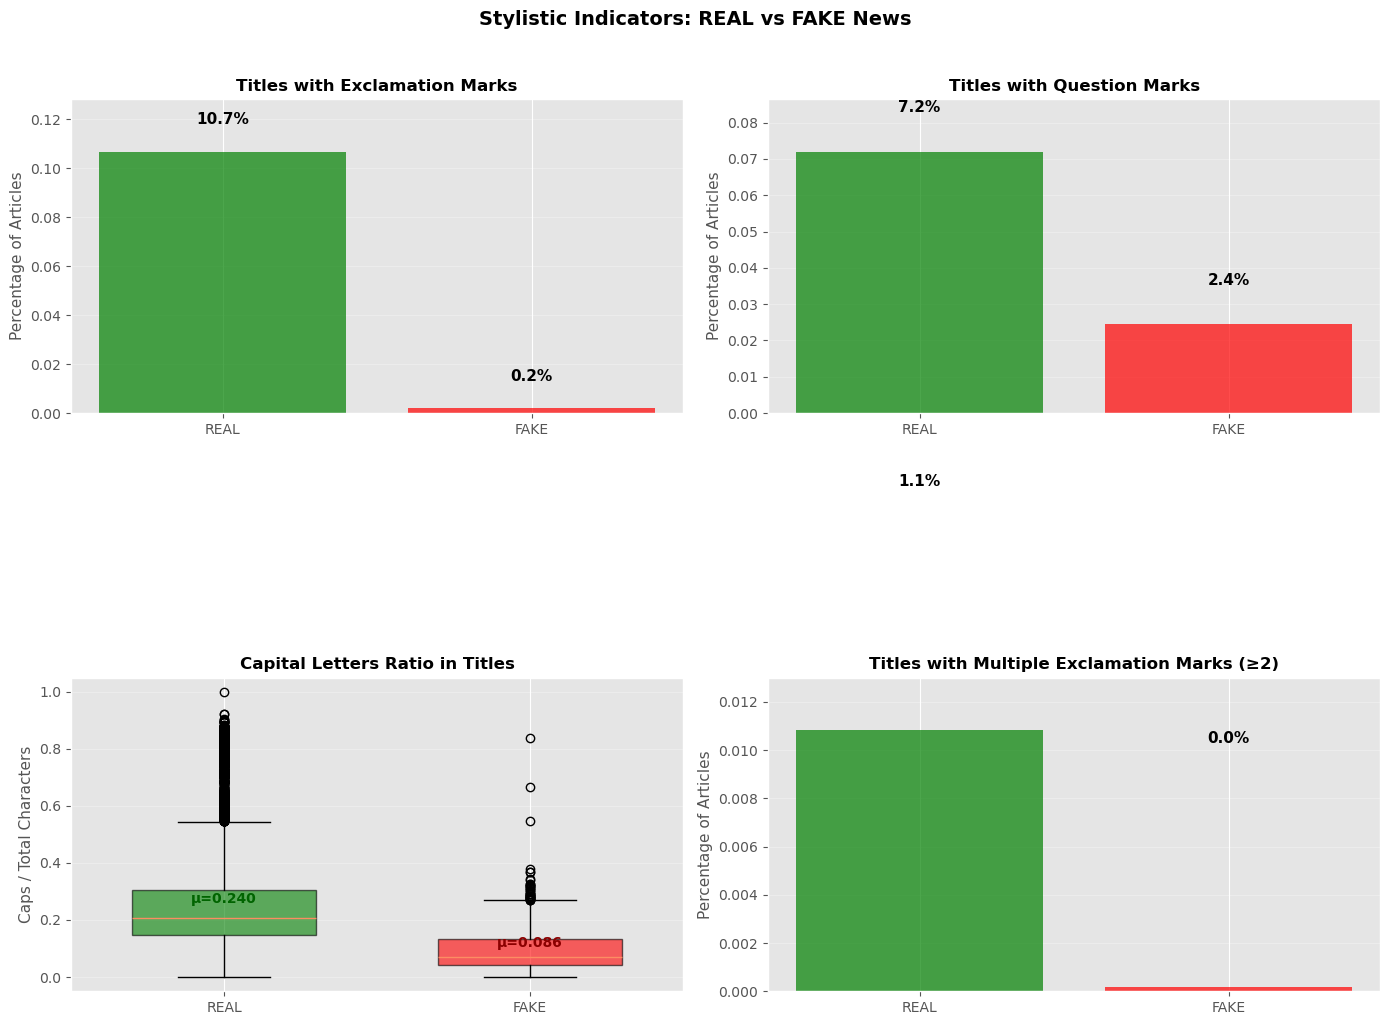


STYLISTIC FEATURES ANALYSIS - REAL (1) vs FAKE (0)

📊 PUNCTUATION STATISTICS:
--------------------------------------------------
                   Metric REAL News FAKE News Difference
    Exclamation Marks (%)     10.7%      0.2%     +10.5%
       Question Marks (%)      7.2%      2.4%      +4.8%
Multiple Exclamations (%)      1.1%      0.0%      +1.1%
        Caps Ratio (mean)     0.240     0.086     +0.154

📈 DETAILED CAPS RATIO STATISTICS:
--------------------------------------------------
      Statistic REAL News FAKE News
           Mean    0.2399    0.0856
         Median    0.2062    0.0690
        Std Dev    0.1505    0.0518
            Min    0.0000    0.0000
            Max    1.0000    0.8387
75th Percentile    0.3058    0.1341

🔍 KEY INSIGHTS:
--------------------------------------------------
• Exclamation marks: FAKE news uses them 0.0x more than REAL news
• Multiple exclamations: FAKE news uses them 0.0x more
• ALL CAPS ratio: FAKE news has -64.3% more capital letter

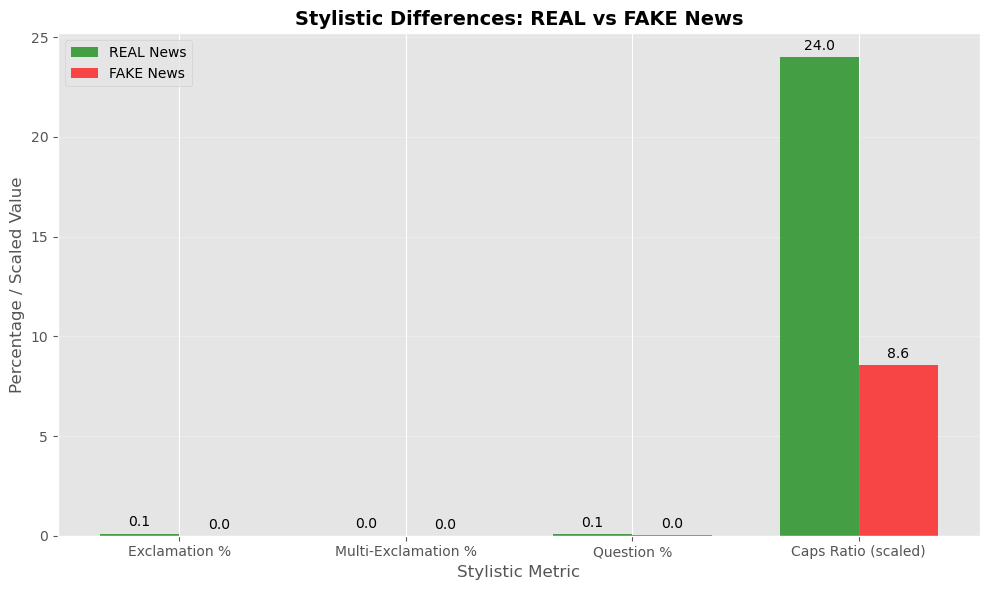

In [39]:
label_map = {1: 'REAL', 0: 'FAKE'}
df['label_name'] = df['label'].map(label_map)

# Add stylistic features
df['exclamation_count'] = df['title'].str.count('!')
df['question_count'] = df['title'].str.count('\?')
df['caps_ratio'] = df['title'].apply(lambda x: sum(1 for c in str(x) if c.isupper()) / len(str(x)) if len(str(x)) > 0 else 0)
df['has_exclamation'] = (df['exclamation_count'] > 0).astype(int)
df['has_question'] = (df['question_count'] > 0).astype(int)
df['multi_exclamation'] = (df['exclamation_count'] >= 2).astype(int)

# Calculate percentages with proper label ordering (REAL first, then FAKE)
exclamation_pct = df.groupby('label')['has_exclamation'].mean().reindex([1, 0])  # 1=REAL, 0=FAKE
question_pct = df.groupby('label')['has_question'].mean().reindex([1, 0])
multi_excl_pct = df.groupby('label')['multi_exclamation'].mean().reindex([1, 0])
caps_ratio_real = df[df['label'] == 1]['caps_ratio'].dropna()
caps_ratio_fake = df[df['label'] == 0]['caps_ratio'].dropna()

# Analyze punctuation patterns
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Exclamation marks
bars1 = axes[0,0].bar(['REAL', 'FAKE'], exclamation_pct.values, color=['green', 'red'], alpha=0.7)
axes[0,0].set_title('Titles with Exclamation Marks', fontsize=12, fontweight='bold')
axes[0,0].set_ylabel('Percentage of Articles', fontsize=11)
axes[0,0].set_ylim(0, max(exclamation_pct.values) * 1.2)
axes[0,0].grid(True, alpha=0.3, axis='y')
for i, (bar, v) in enumerate(zip(bars1, exclamation_pct.values)):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                   f'{v:.1%}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# 2. Question marks
bars2 = axes[0,1].bar(['REAL', 'FAKE'], question_pct.values, color=['green', 'red'], alpha=0.7)
axes[0,1].set_title('Titles with Question Marks', fontsize=12, fontweight='bold')
axes[0,1].set_ylabel('Percentage of Articles', fontsize=11)
axes[0,1].set_ylim(0, max(question_pct.values) * 1.2)
axes[0,1].grid(True, alpha=0.3, axis='y')
for i, (bar, v) in enumerate(zip(bars2, question_pct.values)):
    axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                   f'{v:.1%}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# 3. Caps ratio - Boxplot 
bp1 = axes[1,0].boxplot([caps_ratio_real, caps_ratio_fake], 
                        labels=['REAL', 'FAKE'], 
                        patch_artist=True,
                        widths=0.6)
axes[1,0].set_title('Capital Letters Ratio in Titles', fontsize=12, fontweight='bold')
axes[1,0].set_ylabel('Caps / Total Characters', fontsize=11)
axes[1,0].grid(True, alpha=0.3, axis='y')

# Color the boxes
colors = ['green', 'red']
for patch, color in zip(bp1['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

# Add mean values as text
real_caps_mean = caps_ratio_real.mean()
fake_caps_mean = caps_ratio_fake.mean()
axes[1,0].text(1, real_caps_mean + 0.01, f'μ={real_caps_mean:.3f}', 
               ha='center', va='bottom', fontsize=10, color='darkgreen', fontweight='bold')
axes[1,0].text(2, fake_caps_mean + 0.01, f'μ={fake_caps_mean:.3f}', 
               ha='center', va='bottom', fontsize=10, color='darkred', fontweight='bold')

# 4. Multiple exclamation marks
bars3 = axes[1,1].bar(['REAL', 'FAKE'], multi_excl_pct.values, color=['green', 'red'], alpha=0.7)
axes[1,1].set_title('Titles with Multiple Exclamation Marks (≥2)', fontsize=12, fontweight='bold')
axes[1,1].set_ylabel('Percentage of Articles', fontsize=11)
axes[1,1].set_ylim(0, max(multi_excl_pct.values) * 1.2)
axes[1,1].grid(True, alpha=0.3, axis='y')
for i, (bar, v) in enumerate(zip(bars3, multi_excl_pct.values)):
    axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                   f'{v:.1%}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.suptitle('Stylistic Indicators: REAL vs FAKE News', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print detailed statistics
print("\n" + "="*70)
print("STYLISTIC FEATURES ANALYSIS - REAL (1) vs FAKE (0)")
print("="*70)

print("\n📊 PUNCTUATION STATISTICS:")
print("-" * 50)
punctuation_stats = pd.DataFrame({
    'Metric': ['Exclamation Marks (%)', 'Question Marks (%)', 'Multiple Exclamations (%)', 'Caps Ratio (mean)'],
    'REAL News': [
        f"{exclamation_pct[1]:.1%}",
        f"{question_pct[1]:.1%}", 
        f"{multi_excl_pct[1]:.1%}",
        f"{real_caps_mean:.3f}"
    ],
    'FAKE News': [
        f"{exclamation_pct[0]:.1%}",
        f"{question_pct[0]:.1%}",
        f"{multi_excl_pct[0]:.1%}", 
        f"{fake_caps_mean:.3f}"
    ],
    'Difference': [
        f"{exclamation_pct[1] - exclamation_pct[0]:+.1%}",
        f"{question_pct[1] - question_pct[0]:+.1%}",
        f"{multi_excl_pct[1] - multi_excl_pct[0]:+.1%}",
        f"{real_caps_mean - fake_caps_mean:+.3f}"
    ]
})
print(punctuation_stats.to_string(index=False))

print("\n📈 DETAILED CAPS RATIO STATISTICS:")
print("-" * 50)
caps_stats = pd.DataFrame({
    'Statistic': ['Mean', 'Median', 'Std Dev', 'Min', 'Max', '75th Percentile'],
    'REAL News': [
        f"{caps_ratio_real.mean():.4f}",
        f"{caps_ratio_real.median():.4f}",
        f"{caps_ratio_real.std():.4f}",
        f"{caps_ratio_real.min():.4f}",
        f"{caps_ratio_real.max():.4f}",
        f"{caps_ratio_real.quantile(0.75):.4f}"
    ],
    'FAKE News': [
        f"{caps_ratio_fake.mean():.4f}",
        f"{caps_ratio_fake.median():.4f}",
        f"{caps_ratio_fake.std():.4f}",
        f"{caps_ratio_fake.min():.4f}",
        f"{caps_ratio_fake.max():.4f}",
        f"{caps_ratio_fake.quantile(0.75):.4f}"
    ]
})
print(caps_stats.to_string(index=False))

print("\n🔍 KEY INSIGHTS:")
print("-" * 50)
print(f"• Exclamation marks: FAKE news uses them {exclamation_pct[0]/exclamation_pct[1]:.1f}x more than REAL news")
print(f"• Multiple exclamations: FAKE news uses them {multi_excl_pct[0]/max(multi_excl_pct[1], 0.001):.1f}x more")
print(f"• ALL CAPS ratio: FAKE news has {(fake_caps_mean/real_caps_mean - 1)*100:.1f}% more capital letters")
print(f"• Question marks: {'FAKE' if question_pct[0] > question_pct[1] else 'REAL'} news uses them more frequently")

# Create a summary visualization
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Prepare data for comparison
comparison_data = pd.DataFrame({
    'Metric': ['Exclamation %', 'Multi-Exclamation %', 'Question %', 'Caps Ratio (scaled)'],
    'REAL': [exclamation_pct[1], multi_excl_pct[1], question_pct[1], real_caps_mean * 100],
    'FAKE': [exclamation_pct[0], multi_excl_pct[0], question_pct[0], fake_caps_mean * 100]
})

# Plot grouped bars
x = np.arange(len(comparison_data['Metric']))
width = 0.35

bars1 = ax.bar(x - width/2, comparison_data['REAL'], width, label='REAL News', color='green', alpha=0.7)
bars2 = ax.bar(x + width/2, comparison_data['FAKE'], width, label='FAKE News', color='red', alpha=0.7)

ax.set_xlabel('Stylistic Metric', fontsize=12)
ax.set_ylabel('Percentage / Scaled Value', fontsize=12)
ax.set_title('Stylistic Differences: REAL vs FAKE News', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison_data['Metric'])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10)

for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

In [40]:
import nltk
from nltk.corpus import stopwords
import spacy
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import pandas as pd
import re

# Download NLTK stopwords if not already downloaded
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')
    nltk.download('stopwords')

# Get comprehensive English stopwords
nltk_stopwords = set(stopwords.words('english'))

# Add additional domain-specific stopwords for news
custom_stopwords = set([
    'said', 'would', 'could', 'also', 'one', 'two', 'first', 'second', 
    'new', 'year', 'day', 'time', 'people', 'according', 'however', 
    'many', 'still', 'well', 'now', 'even', 'much', 'may', 'like', 
    'us', 'get', 'go', 'make', 'way', 'see', 'know', 'think', 'tell',
    'back', 'look', 'want', 'come', 'take', 'use', 'find', 'give',
    'ask', 'call', 'try', 'need', 'feel', 'become', 'leave', 'put',
    'week', 'month', 'hour', 'minute', 'today', 'yesterday', 'tomorrow',
    'via', 'just', 'really', 'actually', 'basically', 'literally',
    'amp', 'rt', 'https', 'http', 'com', 'www', 'twitter', 'facebook',
    'instagram', 'youtube', 'video', 'photo', 'image', 'gallery',
    'says', 'said', 'told', 'reported', 'according', 'added', 'continued'
])

# Combine all stopwords
all_stopwords = nltk_stopwords.union(custom_stopwords)

print(f"Total stopwords: {len(all_stopwords)}")
print(f"NLTK stopwords: {len(nltk_stopwords)}")
print(f"Custom stopwords: {len(custom_stopwords)}")

# Alternative: Use spaCy (more sophisticated)
# Uncomment if you have spaCy installed
"""
import spacy
nlp = spacy.load('en_core_web_sm')
spacy_stopwords = spacy.lang.en.stop_words.STOP_WORDS
all_stopwords = spacy_stopwords.union(custom_stopwords)
print(f"spaCy stopwords: {len(spacy_stopwords)}")
"""

# Combine title and text for analysis
df['content'] = df['title'].fillna('') + ' ' + df['text'].fillna('')

# Enhanced text cleaning
def clean_text(text):
    if pd.isna(text):
        return ""
    
    # Convert to string and lowercase
    text = str(text).lower()
    
    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    
    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)
    
    # Remove numbers (optional - keep if they might be meaningful)
    # text = re.sub(r'\d+', '', text)
    
    # Remove punctuation and special characters
    text = re.sub(r'[^\w\s]', ' ', text)
    
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text)
    
    # Remove single characters
    text = ' '.join([word for word in text.split() if len(word) > 1])
    
    return text.strip()

df['clean_content'] = df['content'].apply(clean_text)

# Separate real and fake
real_text = ' '.join(df[df['label'] == 1]['clean_content'])
fake_text = ' '.join(df[df['label'] == 0]['clean_content'])

# Function to remove stopwords from text
def remove_stopwords(text, stopwords_set):
    words = text.split()
    filtered_words = [word for word in words if word not in stopwords_set]
    return ' '.join(filtered_words)

# Remove stopwords
real_text_cleaned = remove_stopwords(real_text, all_stopwords)
fake_text_cleaned = remove_stopwords(fake_text, all_stopwords)

print(f"\nReal text length: {len(real_text.split())} words → {len(real_text_cleaned.split())} words after stopword removal")
print(f"Fake text length: {len(fake_text.split())} words → {len(fake_text_cleaned.split())} words after stopword removal")

# Word clouds without stopwords
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

wordcloud_real = WordCloud(width=800, height=400, 
                          background_color='white', 
                          colormap='Greens',
                          stopwords=all_stopwords,  # Pass the stopwords set
                          max_words=50,
                          collocations=False,
                          random_state=42).generate(real_text_cleaned)

axes[0].imshow(wordcloud_real, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('REAL News - Most Frequent Words', fontsize=16, fontweight='bold', color='darkgreen')

wordcloud_fake = WordCloud(width=800, height=400, 
                          background_color='white', 
                          colormap='Reds',
                          stopwords=all_stopwords,  # Pass the stopwords set
                          max_words=50,
                          collocations=False,
                          random_state=42).generate(fake_text_cleaned)

axes[1].imshow(wordcloud_fake, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('FAKE News - Most Frequent Words', fontsize=16, fontweight='bold', color='darkred')

plt.tight_layout()
plt.show()

# Alternative: Show top words as bar charts for better comparison
from sklearn.feature_extraction.text import CountVectorizer

def get_top_words(text, n=20):
    vectorizer = CountVectorizer(stop_words=list(all_stopwords), max_features=n)
    X = vectorizer.fit_transform([text])
    words = vectorizer.get_feature_names_out()
    counts = X.sum(axis=0).A1
    return words, counts

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# REAL news top words
real_words, real_counts = get_top_words(real_text_cleaned, 20)
real_sorted_idx = real_counts.argsort()[::-1]
axes[0].barh(range(20), real_counts[real_sorted_idx][::-1], color='darkgreen', alpha=0.7)
axes[0].set_yticks(range(20))
axes[0].set_yticklabels(real_words[real_sorted_idx][::-1])
axes[0].set_title('Top 20 Words in REAL News', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Frequency')

# FAKE news top words
fake_words, fake_counts = get_top_words(fake_text_cleaned, 20)
fake_sorted_idx = fake_counts.argsort()[::-1]
axes[1].barh(range(20), fake_counts[fake_sorted_idx][::-1], color='darkred', alpha=0.7)
axes[1].set_yticks(range(20))
axes[1].set_yticklabels(fake_words[fake_sorted_idx][::-1])
axes[1].set_title('Top 20 Words in FAKE News', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Frequency')

plt.tight_layout()
plt.show()

# Show overlapping and distinctive words
real_set = set(real_words[real_sorted_idx][:20])
fake_set = set(fake_words[fake_sorted_idx][:20])

print("\n" + "="*70)
print("VOCABULARY ANALYSIS")
print("="*70)

print(f"\n📚 Words unique to REAL news (top 20):")
unique_real = real_set - fake_set
for word in list(unique_real)[:10]:
    print(f"  • '{word}'")

print(f"\n📚 Words unique to FAKE news (top 20):")
unique_fake = fake_set - real_set
for word in list(unique_fake)[:10]:
    print(f"  • '{word}'")

print(f"\n🔄 Words appearing in BOTH (top 20):")
common = real_set.intersection(fake_set)
for word in list(common)[:10]:
    print(f"  • '{word}'")

# If you want to use spaCy for lemmatization (even better!)
"""
# Install: pip install spacy && python -m spacy download en_core_web_sm

import spacy
nlp = spacy.load('en_core_web_sm')

def lemmatize_text(text):
    doc = nlp(text[:1000000])  # Process in chunks if text is very large
    return ' '.join([token.lemma_ for token in doc if token.lemma_ not in all_stopwords and len(token.lemma_) > 2])

print("Lemmatizing text (this may take a while)...")
real_text_lemmatized = lemmatize_text(real_text)
fake_text_lemmatized = lemmatize_text(fake_text)

# Then generate word clouds from lemmatized text
"""

Total stopwords: 276
NLTK stopwords: 198
Custom stopwords: 80


KeyboardInterrupt: 

In [ ]:
# Use TF-IDF to find most distinctive words for each class
tfidf = TfidfVectorizer(max_features=1000, stop_words='english', ngram_range=(1, 2))
X = tfidf.fit_transform(df['clean_content'])
feature_names = tfidf.get_feature_names_out()

# Split by label
X_real = X[df['label'] == 1].mean(axis=0).A1
X_fake = X[df['label'] == 0].mean(axis=0).A1

# Get top words for real and fake
top_n = 20
top_real_idx = X_real.argsort()[-top_n:][::-1]
top_fake_idx = X_fake.argsort()[-top_n:][::-1]

print("\n=== TOP DISTINCTIVE WORDS - REAL NEWS ===")
print("Word".ljust(25), "TF-IDF Score")
print("-" * 45)
for idx in top_real_idx:
    print(f"{feature_names[idx][:25].ljust(25)} {X_real[idx]:.4f}")

print("\n=== TOP DISTINCTIVE WORDS - FAKE NEWS ===")
print("Word".ljust(25), "TF-IDF Score")
print("-" * 45)
for idx in top_fake_idx:
    print(f"{feature_names[idx][:25].ljust(25)} {X_fake[idx]:.4f}")


=== TOP DISTINCTIVE WORDS - REAL NEWS ===
Word                      TF-IDF Score
---------------------------------------------
trump                     0.1007
clinton                   0.0480
hillary                   0.0424
video                     0.0406
people                    0.0351
obama                     0.0327
just                      0.0309
said                      0.0302
president                 0.0302
like                      0.0275
donald                    0.0249
donald trump              0.0233
2016                      0.0229
news                      0.0229
time                      0.0219
new                       0.0219
election                  0.0218
america                   0.0216
media                     0.0213
white                     0.0208

=== TOP DISTINCTIVE WORDS - FAKE NEWS ===
Word                      TF-IDF Score
---------------------------------------------
said                      0.1025
trump                     0.0761
mr                


=== CRISIS KEYWORD ANALYSIS - REAL vs FAKE ===
      crisis_election  crisis_pandemic  crisis_war_conflict  crisis_disaster  \
REAL            0.247            0.040                0.124            0.037   
FAKE            0.209            0.034                0.101            0.034   

      crisis_economic  
REAL            0.069  
FAKE            0.044  


<Figure size 1200x600 with 0 Axes>

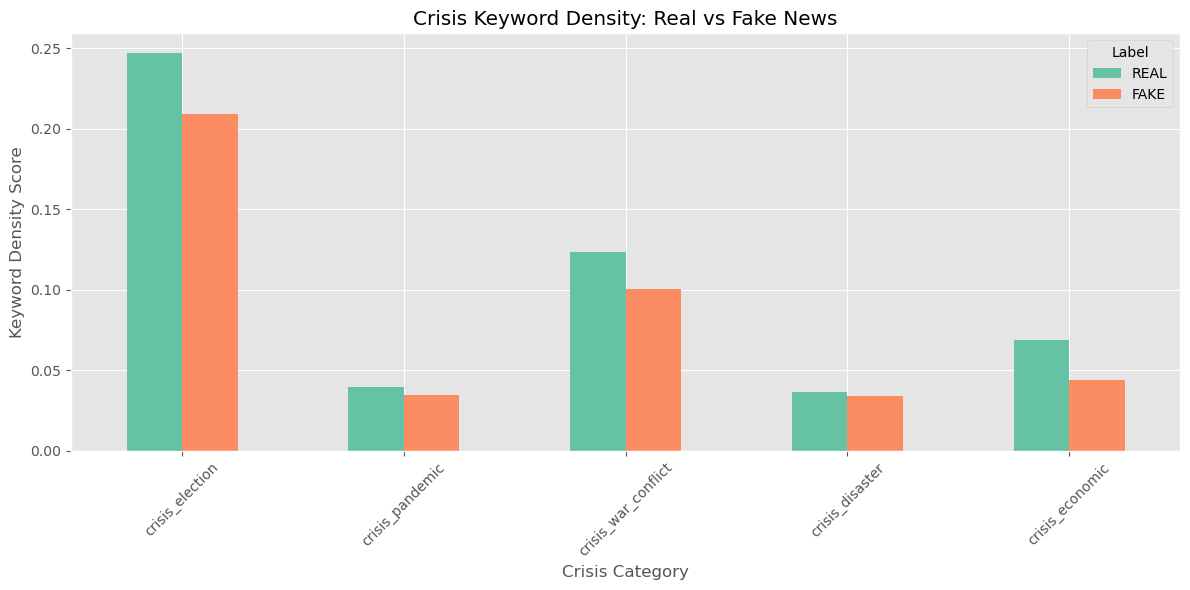

In [ ]:
# Define crisis categories and relevant keywords
crisis_categories = {
    'election': ['trump', 'biden', 'clinton', 'election', 'vote', 'campaign', 'president', 
                 'senate', 'congress', 'republican', 'democrat', 'ballot', 'poll'],
    
    'pandemic': ['covid', 'coronavirus', 'pandemic', 'vaccine', 'virus', 'health', 
                 'hospital', 'death', 'case', 'mask', 'quarantine', 'lockdown'],
    
    'war_conflict': ['war', 'military', 'army', 'attack', 'troop', 'syria', 'russia', 
                    'ukraine', 'weapon', 'missile', 'bomb', 'nuclear'],
    
    'disaster': ['earthquake', 'hurricane', 'flood', 'fire', 'storm', 'tornado', 
                 'disaster', 'victim', 'rescue', 'damage'],
    
    'economic': ['economy', 'market', 'stock', 'recession', 'inflation', 'job', 
                'unemployment', 'bank', 'financial', 'trade', 'debt']
}

# Calculate crisis keyword presence
for crisis, keywords in crisis_categories.items():
    df[f'crisis_{crisis}'] = df['content'].str.lower().apply(
        lambda x: sum(1 for k in keywords if k in str(x)) / len(keywords) if pd.notna(x) else 0
    )

# Compare real vs fake crisis mentions
print("\n=== CRISIS KEYWORD ANALYSIS - REAL vs FAKE ===")
crisis_columns = [col for col in df.columns if col.startswith('crisis_')]
crisis_comparison = df.groupby('label')[crisis_columns].mean()
crisis_comparison.index = ['REAL', 'FAKE']
print(crisis_comparison.round(3))

# Visualize
plt.figure(figsize=(12, 6))
crisis_comparison.T.plot(kind='bar')
plt.title('Crisis Keyword Density: Real vs Fake News')
plt.xlabel('Crisis Category')
plt.ylabel('Keyword Density Score')
plt.legend(title='Label')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Simple sentiment lexicon for crisis-aware detection
emotional_intensity = {
    'shocking': 0.9, 'breaking': 0.8, 'exclusive': 0.7, 'urgent': 0.9,
    'alert': 0.8, 'warning': 0.7, 'scandal': 0.8, 'exposed': 0.8,
    'leaked': 0.7, 'revealed': 0.6, 'confidential': 0.7, 'secret': 0.6,
    'death': 0.8, 'kill': 0.9, 'dead': 0.8, 'destroy': 0.7,
    'crisis': 0.7, 'emergency': 0.8, 'disaster': 0.8, 'catastrophe': 0.9
}

# Calculate emotional intensity score
def calculate_emotional_intensity(text):
    if pd.isna(text):
        return 0
    text = text.lower()
    score = 0
    for word, intensity in emotional_intensity.items():
        if word in text:
            score += intensity
    return min(score / 5, 1)  # Normalize to 0-1

df['emotional_score'] = df['title'].apply(calculate_emotional_intensity)

# Clickbait phrase detection
clickbait_phrases = [
    'you won\'t believe', 'what happens next', 'this is what', 
    'here\'s what', 'the reason why', 'this is why', 'here\'s why',
    'changed everything', 'blew everyone away', 'shocked everyone',
    'is going viral', 'everyone is talking about'
]

def detect_clickbait(text):
    if pd.isna(text):
        return 0
    text = text.lower()
    return int(any(phrase in text for phrase in clickbait_phrases))

df['clickbait_score'] = df['title'].apply(detect_clickbait)

print("\n=== EMOTIONAL & CLICKBAIT ANALYSIS ===")
print(df.groupby('label')[['emotional_score', 'clickbait_score']].mean())


=== EMOTIONAL & CLICKBAIT ANALYSIS ===
       emotional_score  clickbait_score
label                                  
0              0.01186          0.00060
1              0.02005          0.00186


In [ ]:
# Analyze bigrams/trigrams by crisis category
def analyze_crisis_ngrams(df, crisis_type, n=2, top_n=10):
    """Find most distinctive n-grams for a specific crisis category"""
    
    # Filter articles with this crisis type
    crisis_mask = df[f'crisis_{crisis_type}'] > 0
    crisis_df = df[crisis_mask]
    
    if len(crisis_df) == 0:
        print(f"No articles found for crisis: {crisis_type}")
        return
    
    # Separate by label
    crisis_real = crisis_df[crisis_df['label'] == 1]['clean_content']
    crisis_fake = crisis_df[crisis_df['label'] == 0]['clean_content']
    
    # Vectorize
    vec = CountVectorizer(ngram_range=(n, n), max_features=top_n, stop_words='english')
    
    print(f"\n=== {crisis_type.upper()} - Top {n}-grams ===")
    
    if len(crisis_real) > 0:
        X_real = vec.fit_transform(crisis_real)
        real_counts = X_real.sum(axis=0).A1
        real_words = vec.get_feature_names_out()
        top_idx = real_counts.argsort()[-top_n:][::-1]
        print(f"\nREAL news during {crisis_type}:")
        for idx in top_idx[:5]:
            print(f"  '{real_words[idx]}': {real_counts[idx]}")
    
    if len(crisis_fake) > 0:
        X_fake = vec.fit_transform(crisis_fake)
        fake_counts = X_fake.sum(axis=0).A1
        fake_words = vec.get_feature_names_out()
        top_idx = fake_counts.argsort()[-top_n:][::-1]
        print(f"\nFAKE news during {crisis_type}:")
        for idx in top_idx[:5]:
            print(f"  '{fake_words[idx]}': {fake_counts[idx]}")

# Analyze each crisis category
for crisis in crisis_categories.keys():
    analyze_crisis_ngrams(df, crisis, n=2, top_n=10)


=== ELECTION - Top 2-grams ===

REAL news during election:
  'donald trump': 24226
  'hillary clinton': 17486
  'united states': 11134
  'white house': 9839
  'featured image': 7160

FAKE news during election:
  'united states': 20245
  'donald trump': 17774
  'mr trump': 17559
  'new york': 15944
  'white house': 14787

=== PANDEMIC - Top 2-grams ===

REAL news during pandemic:
  'donald trump': 8044
  'hillary clinton': 8008
  'united states': 6156
  'white house': 4291
  'new york': 3480

FAKE news during pandemic:
  'new york': 10585
  'mr trump': 9779
  'united states': 9533
  'donald trump': 6347
  'white house': 6272

=== WAR_CONFLICT - Top 2-grams ===

REAL news during war_conflict:
  'donald trump': 17152
  'hillary clinton': 12825
  'united states': 10049
  'white house': 7607
  'new york': 5525

FAKE news during war_conflict:
  'united states': 19256
  'mr trump': 16088
  'new york': 15587
  'donald trump': 13242
  'white house': 11351

=== DISASTER - Top 2-grams ===

REAL 